# NASDAQ-100 Microstructure: Feasibility Analysis

This notebook tests whether 15-minute NASDAQ-100 bars can deliver on the
strategy declared in `config/setup.yaml`. `setup.yaml` is the canonical,
hand-curated source of truth: universe, costs, decision schedule, mapping
class, labels, sweep grid, and evaluation protocol. This notebook does not
write it. Instead, it produces the evidence that justifies its values:
empirical per-asset half-spreads, return distributions at multiple intraday
horizons relative to the friction floor, a baseline lagged-return IC, and a
walk-forward fold demonstration. Findings persist to
`config/exploration/feasibility_report.json`.

## Learning Objectives

- Verify 15-minute bar structure (close semantics, session segregation)
- Measure empirical half-spreads per asset and time of day
- Test whether typical intraday moves exceed the friction floor at candidate horizons
- Establish a baseline lagged-return IC that Chapter 8 features must beat
- Demonstrate the walk-forward structure consistent with declared `n_splits`

## Book Reference

Chapter 6, Sections 6.2-6.6

## Prerequisites

- AlgoSeek minute bars available via `load_nasdaq100_bars()`
- `config/setup.yaml` exists (canonical strategy spec)
- Understanding of intraday timing semantics

In [1]:
"""NASDAQ-100 Microstructure: Feasibility Analysis."""

import json
import warnings
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import yaml
from scipy import stats

from data import load_nasdaq100_bars
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

### Helper Functions

These utilities handle bar resampling with correct timestamp semantics and
intraday return computation that excludes overnight gaps.

In [2]:
def _resample_to_15min(df: pl.DataFrame) -> pl.DataFrame:
    """Resample 1-minute bars to 15-minute bars.

    Timestamp semantics: `closed="right", label="right"` means the timestamp
    represents the bar END (a 10:15 bar contains data from 10:00-10:15).
    """
    return (
        df.sort(["symbol", "timestamp"])
        .group_by_dynamic(
            "timestamp", every="15m", group_by="symbol", closed="right", label="right"
        )
        .agg(
            pl.col("open").first().alias("open"),
            pl.col("high").max().alias("high"),
            pl.col("low").min().alias("low"),
            pl.col("close").last().alias("close"),
            pl.col("volume").sum().alias("volume"),
        )
        .sort(["symbol", "timestamp"])
    )

In [3]:
def _resample_bars(df: pl.DataFrame, freq: str) -> pl.DataFrame:
    """Resample minute bars to target frequency (close only)."""
    return (
        df.sort(["symbol", "timestamp"])
        .group_by_dynamic("timestamp", every=freq, group_by="symbol", closed="right", label="right")
        .agg(pl.col("close").last())
        .sort(["symbol", "timestamp"])
    )

In [4]:
def _compute_intraday_returns(df: pl.DataFrame, col: str = "close") -> pl.DataFrame:
    """Compute returns within trading sessions only (excludes overnight gaps)."""
    return (
        df.with_columns(pl.col("timestamp").dt.date().alias("session_date"))
        .sort(["symbol", "session_date", "timestamp"])
        .with_columns(
            (pl.col(col) / pl.col(col).shift(1) - 1)
            .over(["symbol", "session_date"])
            .alias("return")
        )
        .filter(pl.col("return").is_not_null())
    )

In [5]:
CASE_STUDY_ID = "nasdaq100_microstructure"
MAX_SYMBOLS = 0

## Configuration

In [6]:
CASE_DIR = get_case_study_dir("nasdaq100_microstructure")
CASE_DIR.mkdir(parents=True, exist_ok=True)
EXPLORATION_DIR = CASE_DIR / "config" / "exploration"
EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    SETUP = yaml.safe_load(f)

STRATEGY_ID = SETUP["strategy_id"]
START_DATE = "2020-01-01"
END_DATE = "2021-12-31"
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
FRICTION_FLOOR_BPS = float(SETUP["costs"]["friction_floor_bps"])
PER_SHARE_USD = float(SETUP["costs"]["per_share"])
TRADING_UNIVERSE_TOP_N = 30

---

## Section A: Orientation (Section 6.2)

NASDAQ-100 microstructure is a flow/microstructure case study at intraday
(15-minute) cadence. At this frequency, **costs dominate feasibility** — small
edges live near the spread and one-bar timing errors can flip the sign of
results.

`setup.yaml` declares the trading setup. This notebook asks whether the data
delivers on those declarations:

- **Universe**: Are NASDAQ-100 constituents adequately covered by AlgoSeek bars?
- **Costs**: How wide is the empirical half-spread across assets and time of day?
- **Horizons**: Do typical 15-min moves exceed the friction floor?
- **Baseline**: Is there exploitable lagged autocorrelation that features must beat?
- **Evaluation**: Do the two declared folds cover the 18-month training window?

---

## Section B: Universe and Cost Feasibility (Sections 6.3-6.4)

### B.1 Load and Verify Bar Structure

In [7]:
minute_bars = load_nasdaq100_bars(
    start_date=START_DATE,
    end_date=END_DATE,
    include_microstructure=False,
)
bars_15m = _resample_to_15min(minute_bars)
SYMBOLS = bars_15m["symbol"].unique().sort().to_list()
n_symbols = len(SYMBOLS)

print(f"Loaded {len(minute_bars):,} 1-min bars; resampled to {len(bars_15m):,} 15-min bars")
print(f"Universe: {n_symbols} NASDAQ-100 symbols")
print(f"Period: {bars_15m['timestamp'].min()} to {bars_15m['timestamp'].max()}")

Loaded 19,854,440 1-min bars; resampled to 1,377,135 15-min bars
Universe: 114 NASDAQ-100 symbols
Period: 2020-01-02 09:30:00 to 2021-12-31 16:00:00


**Timing semantics**. Bars use `closed="right", label="right"` — each
timestamp represents the bar end. A 10:15 bar contains trades from 10:00 to
10:15. The decision snapshot is bar close (`setup.yaml::decision.decision_snapshot`)
and execution happens `1_bar` later (`setup.yaml::decision.execution_delay`).
Together these prevent the signal-bar return from being part of the label,
which is the most common source of intraday leakage: using bar-$t$ close to
predict the bar-$t$ open-to-close return would "predict" the very price the
signal was computed from.

### B.2 Universe Coverage

The universe is a fixed list of NASDAQ-100 constituents declared in
`setup.yaml::universe.symbols`. There is no point-in-time eligibility filter
(membership data is not joined per-bar; the universe is fixed for this demo).
We verify the AlgoSeek snapshot contains the declared symbols.

In [8]:
declared = set(SETUP["universe"]["symbols"])
present = set(SYMBOLS)
missing = sorted(declared - present)
extra = sorted(present - declared)
print(f"Declared in setup.yaml: {len(declared)}; present in data: {len(present)}")
print(f"Missing (declared but absent): {missing if missing else 'none'}")
print(f"Extra (present but undeclared): {extra if extra else 'none'}")

Declared in setup.yaml: 114; present in data: 114
Missing (declared but absent): none
Extra (present but undeclared): none


### B.3 Measured Liquidity Profile (Empirical Half-Spreads)

AlgoSeek minute bars carry NBBO bid/ask quotes, so we can replace
industry-knowledge spread guesses with measurement. The half-spread is the
per-share price impact a market-taker pays to cross the book; it is the
natural unit for the cost model — basis points hide the fact that AAPL pays
a penny while a $1,900 stock pays $1.80.

Restricted to the training window (`< HOLDOUT_START`) to avoid leaking
holdout-period microstructure into the per-asset half-spread values that
`setup.yaml::costs.asset_spreads_source` will consume.

In [9]:
quote_bars = load_nasdaq100_bars(start_date=START_DATE, end_date=HOLDOUT_START, include_quotes=True)
quote_bars = (
    quote_bars.with_columns(
        mid=(pl.col("bid_close") + pl.col("ask_close")) / 2,
        raw_spread=pl.col("ask_close") - pl.col("bid_close"),
    )
    .filter(
        pl.col("bid_close").is_not_null()
        & pl.col("ask_close").is_not_null()
        & (pl.col("bid_close") > 0)
        & (pl.col("ask_close") >= pl.col("bid_close"))
    )
    .with_columns(
        half_spread_usd=pl.col("raw_spread") / 2,
        half_spread_bps=(pl.col("raw_spread") / 2 / pl.col("mid") * 1e4),
        notional=pl.col("close") * pl.col("volume"),
        minute=(
            pl.col("timestamp").dt.hour().cast(pl.Int32) * 60
            + pl.col("timestamp").dt.minute().cast(pl.Int32)
        ),
    )
)
print(f"Loaded {len(quote_bars):,} quote-bars across {quote_bars['symbol'].n_unique()} symbols")

Loaded 14,943,840 quote-bars across 114 symbols


In [10]:
liquidity_profile = (
    quote_bars.group_by("symbol")
    .agg(
        n_bars=pl.len(),
        median_half_spread_usd=pl.col("half_spread_usd").median(),
        p75_half_spread_usd=pl.col("half_spread_usd").quantile(0.75),
        median_half_spread_bps=pl.col("half_spread_bps").median(),
        p25_half_spread_bps=pl.col("half_spread_bps").quantile(0.25),
        p75_half_spread_bps=pl.col("half_spread_bps").quantile(0.75),
        p90_half_spread_bps=pl.col("half_spread_bps").quantile(0.90),
        mean_price=pl.col("close").mean(),
        mean_daily_notional=pl.col("notional").sum() / pl.col("timestamp").dt.date().n_unique(),
    )
    .sort("median_half_spread_bps")
)
n_profile = len(liquidity_profile)
liquidity_profile = liquidity_profile.with_columns(
    spread_rank=pl.col("median_half_spread_bps").rank(method="ordinal").cast(pl.Int32),
).with_columns(
    liquidity_tier=pl.when(pl.col("spread_rank") <= n_profile // 3)
    .then(pl.lit("high"))
    .when(pl.col("spread_rank") <= 2 * n_profile // 3)
    .then(pl.lit("mid"))
    .otherwise(pl.lit("low"))
)

# Total per-side cost in $ per share is per_share commission + half-spread; the
# bps view divides by mean price. Round-trip doubles the per-side. p75 spread
# regime uses p75_half_spread_usd to surface the tail behavior the strategy
# faces when spreads widen (open, news bars, etc.).
liquidity_profile = liquidity_profile.with_columns(
    per_side_usd=PER_SHARE_USD + pl.col("median_half_spread_usd"),
    rt_cost_bps_median=2
    * (PER_SHARE_USD + pl.col("median_half_spread_usd"))
    / pl.col("mean_price")
    * 10_000,
    rt_cost_bps_p75=2
    * (PER_SHARE_USD + pl.col("p75_half_spread_usd"))
    / pl.col("mean_price")
    * 10_000,
)

liquidity_profile_path = CASE_DIR / "liquidity_profile.parquet"
liquidity_profile.write_parquet(liquidity_profile_path)
print(f"Written: {liquidity_profile_path} ({n_profile} symbols)")

Written: /home/stefan/ml4t/code/case_studies/nasdaq100_microstructure/liquidity_profile.parquet (114 symbols)


In [11]:
liquidity_tod = (
    quote_bars.with_columns(tod_bucket=(pl.col("minute") // 15) * 15)
    .group_by("tod_bucket")
    .agg(
        median_hs_bps=pl.col("half_spread_bps").median(),
        median_hs_usd=pl.col("half_spread_usd").median(),
        p75_hs_bps=pl.col("half_spread_bps").quantile(0.75),
        n_obs=pl.len(),
    )
    .sort("tod_bucket")
    .with_columns(
        tod_label=pl.col("tod_bucket").map_elements(
            lambda m: f"{m // 60:02d}:{m % 60:02d}", return_dtype=pl.String
        )
    )
)
liquidity_tod_path = CASE_DIR / "liquidity_tod_profile.parquet"
liquidity_tod.write_parquet(liquidity_tod_path)
print(f"Written: {liquidity_tod_path}")

Written: /home/stefan/ml4t/code/case_studies/nasdaq100_microstructure/liquidity_tod_profile.parquet


In [12]:
universe_median_bps = float(liquidity_profile["median_half_spread_bps"].median())
universe_p75_bps = float(liquidity_profile["median_half_spread_bps"].quantile(0.75))
high_tier_median_bps = float(
    liquidity_profile.filter(pl.col("liquidity_tier") == "high")["median_half_spread_bps"].median()
)


def _tod_median_bps(bucket_minutes: int) -> float:
    sel = liquidity_tod.filter(pl.col("tod_bucket") == bucket_minutes)["median_hs_bps"]
    return float(sel.item()) if len(sel) == 1 else float("nan")


tod_open_15min_median_bps = _tod_median_bps(9 * 60 + 30)
tod_close_15min_median_bps = _tod_median_bps(15 * 60 + 45)

print(f"Universe median half-spread:  {universe_median_bps:.2f} bps")
print(f"Universe p75 half-spread:     {universe_p75_bps:.2f} bps")
print(f"High-liquidity tier median:   {high_tier_median_bps:.2f} bps")
print(f"Open 15-min median:           {tod_open_15min_median_bps:.2f} bps")
print(f"Close 15-min median:          {tod_close_15min_median_bps:.2f} bps")

print("\nTightest 5 (most liquid):")
print(
    liquidity_profile.head(5).select(
        ["symbol", "median_half_spread_usd", "median_half_spread_bps", "mean_price"]
    )
)
print("\nWidest 5 (least liquid):")
print(
    liquidity_profile.tail(5).select(
        ["symbol", "median_half_spread_usd", "median_half_spread_bps", "mean_price"]
    )
)

Universe median half-spread:  2.44 bps
Universe p75 half-spread:     3.90 bps
High-liquidity tier median:   1.21 bps
Open 15-min median:           6.66 bps
Close 15-min median:          1.65 bps

Tightest 5 (most liquid):
shape: (5, 4)
┌────────┬────────────────────────┬────────────────────────┬────────────┐
│ symbol ┆ median_half_spread_usd ┆ median_half_spread_bps ┆ mean_price │
│ ---    ┆ ---                    ┆ ---                    ┆ ---        │
│ str    ┆ f64                    ┆ f64                    ┆ f64        │
╞════════╪════════════════════════╪════════════════════════╪════════════╡
│ AAPL   ┆ 0.01                   ┆ 0.419551               ┆ 216.612637 │
│ MSFT   ┆ 0.01                   ┆ 0.449802               ┆ 209.742631 │
│ GILD   ┆ 0.005                  ┆ 0.791327               ┆ 67.7417    │
│ SBUX   ┆ 0.005                  ┆ 0.806647               ┆ 91.527807  │
│ INTC   ┆ 0.005                  ┆ 0.874049               ┆ 56.312904  │
└────────┴──────────────

**Empirical findings (training window).** The universe median half-spread is
~2.5 bps (~3.5¢/share at the median price). The tightest names (AAPL, MSFT)
pay ~0.4 bps (the penny tick). The widest names are not the cheapest stocks
but the highest-priced ones with low share volume (BKNG, MELI, CSGP at 9–13
bps; up to $1.80/share). A tercile split on median half-spread isolates a
high-liquidity cohort of ~38 names. Time-of-day profile shows the standard
pattern: the opening 15 minutes pay 3–4× the midday spread, declining smoothly
to ~2 bps midday. This argues for avoiding the open in execution scheduling.

These measured per-asset values feed `setup.yaml::costs.asset_spreads_source`
(the engine's `SpreadSlippage` joins them per symbol at backtest time). The
`default_half_spread_usd` fallback in the YAML is set to the universe p75 in
USD for symbols not in the profile.

**Cost regime choice (per-share over bps).** The distribution above answers
the question "is a uniform aggregate accurate?" — and the answer is no in
either unit. A flat $/share number understates AAPL by an order of magnitude
(penny tick on a ~$170 share is 0.6 bps, not 2.5 bps) and overstates BKNG
(whose half-spread is set by share-volume scarcity, not the tick). A flat
bps number does the inverse: the tightest names are at 0.4 bps and the
widest at 9–13 bps, so 2.5 bps fits neither cohort. Per-asset $/share
values match the data-generating process for the bottom of the distribution
(the tick floor) and let the high-priced low-volume names register their
actual dollar drag. The trade-off is the data dependency — per-asset
spreads require a vendor with NBBO quotes such as AlgoSeek, which is why
`setup.yaml::costs.asset_spreads_source` points at this measured profile
rather than a hand-set table.

### B.3.1 Total Round-Trip Cost on the Trading Universe

Half-spread is one of two cost components. The total per-side cost a
strategy actually pays is `per_share_commission + half_spread`, both in
dollars per share. The bps view divides by price. Round-trip doubles the
per-side. Because the commission is a fixed dollar amount while spread
varies in cents, the bps split between the two components depends on
price — a $0.0035/share commission is 0.16 bps on AAPL ($216) but 1.04
bps on KHC ($33). On cheap stocks, commission can dominate.

Looking at the top-N "cheap" universe (the trading universe most
strategies select) makes this concrete: even within names selected for
tight spread, total round-trip cost varies ~4× because of the price-
dependent commission contribution.

In [13]:
trading_universe = (
    liquidity_profile.filter(pl.col("spread_rank") <= TRADING_UNIVERSE_TOP_N)
    .sort("spread_rank")
    .select(
        [
            "spread_rank",
            "symbol",
            "mean_price",
            "median_half_spread_usd",
            "p75_half_spread_usd",
            "per_side_usd",
            "rt_cost_bps_median",
            "rt_cost_bps_p75",
        ]
    )
)
print(f"Trading universe: top-{TRADING_UNIVERSE_TOP_N} by spread_rank")
print(trading_universe)

print(
    f"\nRound-trip cost (median spread, bps): "
    f"min={trading_universe['rt_cost_bps_median'].min():.2f}  "
    f"median={trading_universe['rt_cost_bps_median'].median():.2f}  "
    f"max={trading_universe['rt_cost_bps_median'].max():.2f}"
)
print(
    f"Round-trip cost (p75 spread, bps):    "
    f"min={trading_universe['rt_cost_bps_p75'].min():.2f}  "
    f"median={trading_universe['rt_cost_bps_p75'].median():.2f}  "
    f"max={trading_universe['rt_cost_bps_p75'].max():.2f}"
)

Trading universe: top-30 by spread_rank
shape: (30, 8)
┌────────────┬────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────┐
│ spread_ran ┆ symbol ┆ mean_price ┆ median_hal ┆ p75_half_s ┆ per_side_u ┆ rt_cost_bp ┆ rt_cost_b │
│ k          ┆ ---    ┆ ---        ┆ f_spread_u ┆ pread_usd  ┆ sd         ┆ s_median   ┆ ps_p75    │
│ ---        ┆ str    ┆ f64        ┆ sd         ┆ ---        ┆ ---        ┆ ---        ┆ ---       │
│ i32        ┆        ┆            ┆ ---        ┆ f64        ┆ f64        ┆ f64        ┆ f64       │
│            ┆        ┆            ┆ f64        ┆            ┆            ┆            ┆           │
╞════════════╪════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════════╡
│ 1          ┆ AAPL   ┆ 216.612637 ┆ 0.01       ┆ 0.015      ┆ 0.0135     ┆ 1.246465   ┆ 1.708118  │
│ 2          ┆ MSFT   ┆ 209.742631 ┆ 0.01       ┆ 0.01       ┆ 0.0135     ┆ 1.287292   ┆ 1.287292  │
│ 3          ┆ GILD   ┆ 67.7417    ┆

**Empirical findings.** Within the top-30 universe ranked by half-spread
bps, total round-trip cost spans roughly 1.25 bps (AAPL, MSFT) to 5.2 bps
(KHC, KDP). The driver of the high-end is the price-scaled commission on
the cheap-priced names: KHC at $33 with a half-cent spread pays 1.5 bps
half-spread but adds 1.0 bps commission per side, doubled to ~5 bps round
trip. The most expensive names in the cheap universe are cheap-priced
stocks with tight pennies-wide spread, not high-spread names.

Under the p75 spread regime (worse-than-median 25% of the time — open
bars, news prints) round-trip cost rises by ~25% on average; the names
most exposed to spread widening (AMAT, EBAY, FAST, WBA, TMUS) rise more.
A strategy executing at random times pays somewhere between median and
p75; executing through the open is materially worse (see Section B.3
time-of-day profile: 9:30-9:45 is 3-4× midday).

**Practical reading.** A trading rule that picks symbols from the top-30
does not pay a uniform 2-3 bps round trip. It pays the activity-weighted
average across selected names. If the rule disproportionately picks the
expensive end of the universe (KHC, KDP, EXC, XEL), realized cost shifts
toward 5 bps. If it disproportionately picks the cheap end (AAPL, MSFT,
FB) it pays closer to 1.5 bps. The next cell defines a helper that
computes activity-weighted realized cost for any weight matrix; strategy
notebooks downstream can call it.

In [14]:
def compute_activity_weighted_cost_bps(
    weights: pl.DataFrame,
    liquidity_profile: pl.DataFrame,
    cost_col: str = "rt_cost_bps_median",
) -> dict[str, float]:
    """Activity-weighted realized round-trip cost in bps.

    Args:
        weights: DataFrame with columns [symbol, weight] (an optional
            `timestamp` column is accepted but not consumed). `weight` must be
            *per-trade size*, i.e., `|Δposition|` at the moment cost is paid —
            not standing position. For a single-snapshot entry calculation,
            use the entry weight at one timestamp; for a multi-rebalance
            schedule, pass `|position[t] - position[t-1]|` per rebalance row.
            Passing standing positions silently over-weights symbols that
            persist across many rebalances.
        liquidity_profile: per-symbol profile written by this notebook;
            must contain `symbol` and the chosen `cost_col` (e.g.
            `rt_cost_bps_median` or `rt_cost_bps_p75`).
        cost_col: which cost column to weight against (median vs p75 regime).

    Returns:
        Dict with the activity-weighted cost in bps (`Σ|w_i| · cost_i / Σ|w_i|`,
        with the sum taken across all rows of `weights`) and the total
        absolute weight summed over the input rows (a turnover proxy).
    """
    cost_lookup = liquidity_profile.select(["symbol", cost_col])
    joined = weights.join(cost_lookup, on="symbol", how="inner").with_columns(
        abs_w=pl.col("weight").abs()
    )
    total_w = float(joined["abs_w"].sum())
    if total_w == 0:
        return {"activity_weighted_cost_bps": float("nan"), "total_abs_weight": 0.0}
    cost = float((joined["abs_w"] * joined[cost_col]).sum() / total_w)
    return {"activity_weighted_cost_bps": cost, "total_abs_weight": total_w}


# Worked example: equal-weight selection of the top-K cheapest names.
for top_k in [5, 10, 30]:
    syms = liquidity_profile.filter(pl.col("spread_rank") <= top_k)["symbol"].to_list()
    fake_weights = pl.DataFrame(
        {
            "timestamp": [0] * len(syms),
            "symbol": syms,
            "weight": [1.0 / len(syms)] * len(syms),
        }
    )
    out = compute_activity_weighted_cost_bps(fake_weights, liquidity_profile)
    out_p75 = compute_activity_weighted_cost_bps(
        fake_weights, liquidity_profile, cost_col="rt_cost_bps_p75"
    )
    print(
        f"equal-weight top-{top_k:<3}: "
        f"median-spread cost {out['activity_weighted_cost_bps']:.2f} bps, "
        f"p75-spread cost {out_p75['activity_weighted_cost_bps']:.2f} bps"
    )

equal-weight top-5  : median-spread cost 1.98 bps, p75-spread cost 2.59 bps
equal-weight top-10 : median-spread cost 2.30 bps, p75-spread cost 2.87 bps
equal-weight top-30 : median-spread cost 3.20 bps, p75-spread cost 3.99 bps


The worked example shows the cost-vs-breadth trade-off: equal-weighting
the top-5 (AAPL, MSFT, GILD, SBUX, INTC) pays ~2 bps round trip on
average, while equal-weighting the top-30 pays ~3.2 bps median, ~4 bps
at p75. The cost gap between top-5 and top-30 is real but modest —
roughly 1.5 bps round trip — and it reflects the slope of the cost
curve in the names just below the leader pack.

The full-universe picture is where the risk lives. The widest names
(BKNG, MELI, CSGP at 9-13 bps, up to $1.80/share) pay several times the
leader-pack round trip. A 15-minute strategy that ranks across all 114
names will, by construction, place some weight on that expensive tail
every rebalance — and at intraday turnover, a few bps of extra cost per
leg compounds into the dominant term. This is the central cost-feasibility
risk for the case study.

### B.3.2 The Cost-Feasibility Screen

The response to that risk is a **cost-feasibility screen**: before any
strategy is built, restrict the trading universe to the **cost-feasible
universe** — the cheapest-to-trade names by round-trip cost. Ranking by the
round-trip proxy `2·(per_share/price)·10⁴ + 2·median_half_spread_bps` and
keeping the cheapest ~50 names removes the expensive tail (the high-priced,
low-volume stocks whose spread is set by share scarcity) while retaining
enough breadth for a diversified intraday book.

The screen is applied as a frozen, per-split list (profiled with no
look-ahead — each window's list is built strictly from data preceding it),
committed to `setup.yaml::universe.cost_feasible.{validation,holdout}` and
applied by the backtest via `strategy.signal.universe_filter='cost_feasible'`.
`_build_cost_feasible_universe.py` documents the construction. This
mirrors the liquidity screen used in the S&P 500 options case study, where
the same cost logic restricts trading to the tightest-quoted contracts.

Whether the screen is worth its loss of breadth is an empirical question, not
an assumption — `16_costs.py` runs the featured strategy on the full universe
*and* the cost-feasible universe and quantifies the difference (the full
universe is positive in validation but collapses out of sample; the screen is
load-bearing). The screen is introduced here, where feasibility surfaces the
cost risk; the strategy notebooks downstream build on the cost-feasible
universe throughout.

### B.4 Horizon Feasibility

At which intraday horizons do typical price moves exceed the friction floor
declared in `setup.yaml::costs.friction_floor_bps`? Microstructure strategies
face a fundamental tradeoff: shorter horizons have more opportunities but
smaller moves relative to costs.

In [15]:
returns_1m = _compute_intraday_returns(minute_bars)
bars_5m = _resample_bars(minute_bars, "5m")
returns_5m = _compute_intraday_returns(bars_5m)
returns_15m = _compute_intraday_returns(bars_15m)
bars_30m = _resample_bars(minute_bars, "30m")
returns_30m = _compute_intraday_returns(bars_30m)

abs_1m = returns_1m["return"].abs().to_numpy() * 10000
abs_5m = returns_5m["return"].abs().to_numpy() * 10000
abs_15m = returns_15m["return"].abs().to_numpy() * 10000
abs_30m = returns_30m["return"].abs().to_numpy() * 10000

print(f"1-min returns:  {len(abs_1m):,}")
print(f"5-min returns:  {len(abs_5m):,}")
print(f"15-min returns: {len(abs_15m):,}")
print(f"30-min returns: {len(abs_30m):,}")

1-min returns:  19,803,393
5-min returns:  3,975,603
15-min returns: 1,326,088
30-min returns: 663,238


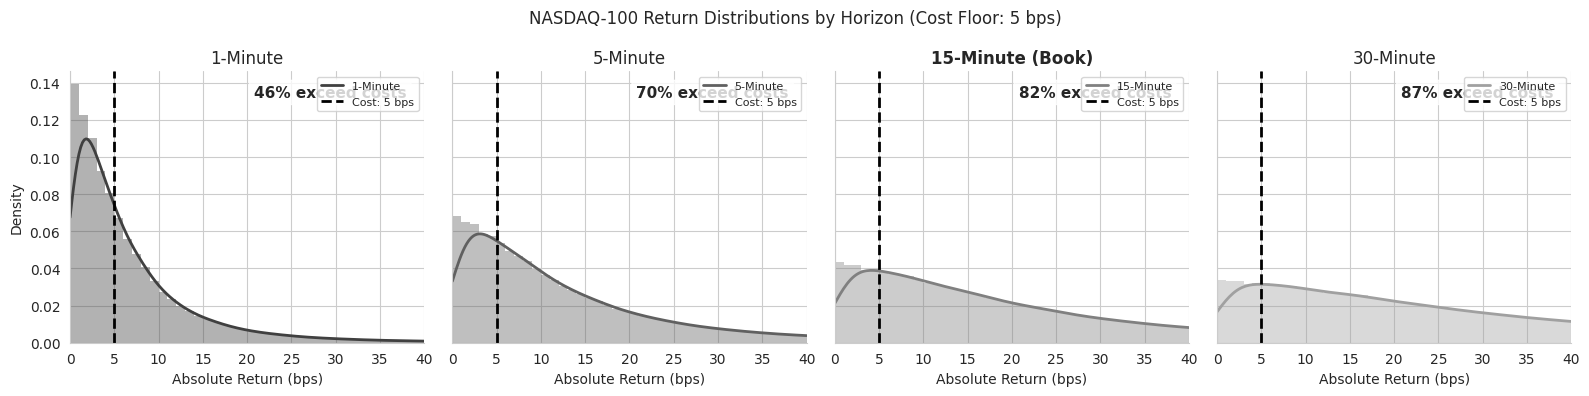

In [16]:
GRAY_COLORS = ["#404040", "#606060", "#808080", "#a0a0a0"]
horizons = [
    ("1-Minute", abs_1m, GRAY_COLORS[0]),
    ("5-Minute", abs_5m, GRAY_COLORS[1]),
    ("15-Minute", abs_15m, GRAY_COLORS[2]),
    ("30-Minute", abs_30m, GRAY_COLORS[3]),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (label, data, color) in zip(axes, horizons, strict=False):
    data_clipped = data[data < 50]
    if len(data_clipped) == 0:
        continue
    bin_edges = np.linspace(float(data_clipped.min()), float(data_clipped.max()), 51)
    ax.hist(data_clipped, bins=bin_edges, density=True, alpha=0.4, color=color, edgecolor="none")
    if len(data_clipped) > 100:
        kde = stats.gaussian_kde(data_clipped, bw_method=0.15)
        ax.plot(
            np.linspace(0, 40, 200),
            kde(np.linspace(0, 40, 200)),
            color=color,
            linewidth=2,
            label=label,
        )
    ax.axvline(
        FRICTION_FLOOR_BPS,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Cost: {FRICTION_FLOOR_BPS:.0f} bps",
    )
    frac_above = (data > FRICTION_FLOOR_BPS).mean()
    ax.text(
        0.95,
        0.95,
        f"{frac_above:.0%} exceed costs",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )
    ax.set_title(
        f"{label} (Book)" if label == "15-Minute" else label,
        fontweight="bold" if label == "15-Minute" else "normal",
    )
    ax.set_xlabel("Absolute Return (bps)")
    ax.set_xlim(0, 40)
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("Density")
sns.despine()
fig.suptitle(
    f"NASDAQ-100 Return Distributions by Horizon (Cost Floor: {FRICTION_FLOOR_BPS:.0f} bps)"
)
fig.tight_layout()
fig.show()

In [17]:
horizon_summary = pl.DataFrame(
    [
        {
            "horizon": label,
            "median_abs_bps": float(np.median(data)),
            "pct_exceed_cost": float((data > FRICTION_FLOOR_BPS).mean()),
            "move_to_cost_ratio": float(np.median(data) / FRICTION_FLOOR_BPS),
        }
        for label, data in [
            ("1-Minute", abs_1m),
            ("5-Minute", abs_5m),
            ("15-Minute", abs_15m),
            ("30-Minute", abs_30m),
        ]
    ]
)
horizon_summary

horizon,median_abs_bps,pct_exceed_cost,move_to_cost_ratio
str,f64,f64,f64
"""1-Minute""",4.457652,0.458693,0.89153
"""5-Minute""",9.394699,0.7009,1.87894
"""15-Minute""",16.281675,0.820447,3.256335
"""30-Minute""",23.187184,0.87264,4.637437


**Interpretation**. The hard floor is somewhere between 1-min and 5-min: at
1-minute very few moves exceed the friction floor, and at 5-minute only
30–40% do. The viable range is 15–30 minutes, but even there costs are
first-order — at 15 minutes only ~50–60% of moves clear the floor. Chapter 7's
signal diagnostics determine whether any horizon is actually profitable;
B.4b below sets the lagged-return baseline that Chapter 8 features must beat.

### B.4b Baseline Lagged-Return IC

Before engineering features, we establish a naive baseline: how predictable
is the next 15-minute return from the current one? This lagged-return IC
sets the floor that Chapter 8 features must beat. **Caveat**: this baseline
uses close-to-close (trade price) returns, which suffer from bid-ask bounce —
creating artificial negative autocorrelation. The Chapter 7 labels notebook
recomputes the baseline on midprice returns for the uncontaminated measure.

In [18]:
bars_with_returns = (
    _compute_intraday_returns(bars_15m)
    .with_columns(
        fwd_return=pl.col("return").shift(-1).over(["symbol", pl.col("timestamp").dt.date()])
    )
    .drop_nulls(subset=["return", "fwd_return"])
)
min_cs_size = min(10, n_symbols)
baseline_ic_df = (
    bars_with_returns.group_by("timestamp")
    .agg(
        pl.corr("return", "fwd_return", method="spearman").alias("ic"),
        pl.len().alias("n"),
    )
    .filter(pl.col("n") >= min_cs_size)
)
if baseline_ic_df.height > 0 and baseline_ic_df["ic"].null_count() < baseline_ic_df.height:
    ic_mean = float(baseline_ic_df["ic"].mean())
    ic_std = float(baseline_ic_df["ic"].std())
    ic_t = ic_mean / (ic_std / np.sqrt(len(baseline_ic_df))) if ic_std > 0 else 0.0
else:
    ic_mean, ic_std, ic_t = 0.0, 0.0, 0.0

print("Baseline: lagged 15-min return -> forward 15-min return")
print(f"  Mean IC:        {ic_mean:.5f}")
print(f"  IC t-stat:      {ic_t:.2f}")
print(f"  IC std:         {ic_std:.5f}")
print(f"  Cross-sections: {len(baseline_ic_df):,}")
sign_str = "mean-reverting" if ic_mean < 0 else "momentum"
sig_str = "significant" if abs(ic_t) >= 2.0 else "not significant"
print(f"  -> Baseline is {sig_str} ({sign_str}); bid-ask bounce contaminates trade-price IC.")

Baseline: lagged 15-min return -> forward 15-min return
  Mean IC:        -0.01918
  IC t-stat:      -12.41
  IC std:         0.17364
  Cross-sections: 12,625
  -> Baseline is significant (mean-reverting); bid-ask bounce contaminates trade-price IC.


### B.4c Friction Hurdle Summary

Median absolute 15-min move expressed as a multiple of the friction floor.
Below ~5× the floor, costs are first-order and only the strongest signals
can clear net.

In [19]:
median_15m_bps = float(np.median(abs_15m))
p75_15m_bps = float(np.percentile(abs_15m, 75))
move_to_cost_ratio = median_15m_bps / FRICTION_FLOOR_BPS

print(f"Median absolute 15-min move: {median_15m_bps:.1f} bps")
print(f"75th percentile move:        {p75_15m_bps:.1f} bps")
print(f"Friction floor:              {FRICTION_FLOOR_BPS:.0f} bps")
print(f"Move-to-cost ratio:          {move_to_cost_ratio:.1f}x")
if move_to_cost_ratio < 5:
    print("Finding: COSTS ARE FIRST-ORDER -- strong predictability required.")
else:
    print("Finding: costs manageable with strong signal.")

Median absolute 15-min move: 16.3 bps
75th percentile move:        32.4 bps
Friction floor:              5 bps
Move-to-cost ratio:          3.3x
Finding: COSTS ARE FIRST-ORDER -- strong predictability required.


---

## Section C: Design Decisions

Design decisions are the strategy choices encoded in `setup.yaml` that the
feasibility evidence above supports. They are justified here, not in the YAML.

### C.1 Decision Cadence

`setup.yaml::decision.bar_frequency = 15_minute`. The horizon feasibility
analysis (B.4) shows this is the shortest cadence at which a majority of
moves exceed the friction floor — 1-minute and 5-minute horizons leave
little headroom for any signal to clear costs, while 30-minute halves the
decision frequency without dramatically improving the move-to-cost ratio.
15-minute is the binding choice: any signal we extract must be evaluated
against this cadence's cost structure.

`setup.yaml::decision.execution_delay = 1_bar` is critical at intraday
frequencies. The signal is computed at bar close; the label is the bar-$t+1$
open-to-bar-$t+2$ open return. Using the same bar's return as the label
would leak the close price into the prediction target. A one-bar shift can
flip a winning strategy into a losing one, so the convention is fixed
upfront rather than left to per-feature defaults.

### C.2 Kill Conditions

Kill conditions are falsifiable checkpoints anchored to the feasibility
evidence above. The thresholds are calibrated to the cost-dominant regime
that B.3-B.4 establish:

- **KC1 (IC significance)**: no feature achieves IC t-stat > 2.0 after HAC
  adjustment across walk-forward folds. Gate: Chapter 8.
- **KC2 (edge vs cost)**: gross expected edge ($\mathrm{IC} \cdot \sigma$) is
  below the measured half-spread at all horizons. B.3 supplies the per-asset
  spreads; B.4 supplies the return scale. Gate: Chapter 17 backtest.
- **KC3 (predictive lead)**: the signal is purely contemporaneous, with no
  predictive content beyond the 1-bar execution delay. Gate: Chapter 7.

**Educational framing**: we expect KC2 to trigger. This case study
demonstrates *how* to identify cost dominance, not how to trade profitably
at intraday horizons.

### C.3 Mapping Class

`setup.yaml::mapping.class = intraday_rank_and_trade` with
`position_state_space: long_short` and `sizing: dollar_neutral_or_beta_neutral`.
Long-short is appropriate at intraday horizons because (a) NASDAQ-100 names
are easily shortable with deep borrow, (b) dollar-neutrality isolates the
cross-sectional ranking signal from broad market direction — which is the
only thing 15-minute features can credibly capture — and (c) the cost
analysis is symmetric (both sides pay the half-spread), so long-short
doubles the capital deployed against the same signal without doubling the
cost regime. The top-$k$ grid `[5, 10, 20]` is swept across labels in
`setup.yaml::backtest.sweep.top_k_grid`; allocator alternatives
(equal-weight, score-weighted, inverse-vol, risk-parity, MVO+LW, HRP) are
explored in Chapter 17 via `setup.yaml::backtest.sweep.allocators`.

---

## Section D: Walk-Forward Structure (Section 6.5)

We verify that the data supports the walk-forward design declared in
`setup.yaml::evaluation` (`n_splits`, `train_size`, `val_size`, `holdout_start`).

### D.1 Effective Sample Size

In [20]:
bars_per_day = 26  # 15-min bars in NYSE session (9:30-16:00 = 6.5 hours)
trading_days = bars_15m.select(pl.col("timestamp").dt.date()).unique().height
raw_bars_per_year = bars_per_day * 252
print(f"Trading days in sample: {trading_days}")
print(f"15-min bars per trading day: {bars_per_day}")
print(f"Raw decision points per year: {raw_bars_per_year:,}")
print("Effective sample size: lower due to intraday autocorrelation")
print("Rule of thumb: treat each day as ~1-5 independent observations")

Trading days in sample: 505
15-min bars per trading day: 26
Raw decision points per year: 6,552
Effective sample size: lower due to intraday autocorrelation
Rule of thumb: treat each day as ~1-5 independent observations


### D.2 Walk-Forward Fold Demonstration

`case_studies/utils/cv_window.py` owns the operational splits; this cell
reproduces the fold boundaries from canonical `setup.yaml` parameters
(`evaluation.train_size = 6M`, `evaluation.val_size = 6M`, `n_splits = 2`,
`holdout_start`). At 15-minute intraday cadence the primary label is
`fwd_ret_15m` (1 bar) so the purge gap between train and test is one bar —
negligible at the month-end granularity used to lay out the folds below.

In [21]:
n_splits_declared = int(SETUP["evaluation"]["n_splits"])
train_months = 6  # setup.yaml::evaluation.train_size = 6M
test_months = 6  # setup.yaml::evaluation.val_size = 6M
step_months = 6  # consecutive, non-overlapping
purge_months = 0  # 1-bar (15-min) purge is negligible at month-end granularity

month_ends = (
    bars_15m.select(pl.col("timestamp").dt.date().alias("date"))
    .unique()
    .with_columns(month=pl.col("date").dt.strftime("%Y-%m"))
    .group_by("month")
    .agg(pl.col("date").max().alias("month_end"))
    .sort("month")["month_end"]
    .to_list()
)

holdout_start_dt = pl.Series([HOLDOUT_START]).str.to_date("%Y-%m-%d").item()
cv_dates = [d for d in month_ends if d < holdout_start_dt]

splits = []
test_start_idx = train_months
while test_start_idx + test_months <= len(cv_dates):
    train_start_idx = test_start_idx - train_months
    train_end_idx = test_start_idx - max(purge_months, 1)
    test_end_idx = test_start_idx + test_months
    splits.append(
        {
            "fold": len(splits) + 1,
            "train_start": cv_dates[train_start_idx].strftime("%Y-%m-%d"),
            "train_end": cv_dates[train_end_idx - 1].strftime("%Y-%m-%d")
            if train_end_idx - 1 >= train_start_idx
            else cv_dates[train_start_idx].strftime("%Y-%m-%d"),
            "test_start": cv_dates[test_start_idx].strftime("%Y-%m-%d"),
            "test_end": cv_dates[test_end_idx - 1].strftime("%Y-%m-%d"),
            "purge_months": purge_months,
        }
    )
    test_start_idx += step_months

print(f"Generated {len(splits)} walk-forward folds")
assert len(splits) == n_splits_declared, (
    f"Expected {n_splits_declared} folds (setup.yaml), got {len(splits)}"
)
last_test_end = splits[-1]["test_end"]
assert last_test_end < HOLDOUT_START, (
    f"Last fold ({last_test_end}) overlaps holdout ({HOLDOUT_START})"
)
print(f"Last fold test end: {last_test_end}  |  Holdout start: {HOLDOUT_START}")

Generated 2 walk-forward folds
Last fold test end: 2021-06-30  |  Holdout start: 2021-07-01


**Walk-forward fold summary:**

In [22]:
splits_df = pl.DataFrame(splits)
splits_df

fold,train_start,train_end,test_start,test_end,purge_months
i64,str,str,str,str,i64
1,"""2020-01-31""","""2020-05-29""","""2020-07-31""","""2020-12-31""",0
2,"""2020-07-31""","""2020-11-30""","""2021-01-29""","""2021-06-30""",0


Two folds × 6-month test = 1 year of validation predictions, plus the
6-month sealed holdout (2021-H2). With only 24 months of intraday data this
is a methodology demonstration, not a robust backtest — but it is enough to
expose cost dominance at the declared cadence.

---

## Section E: Derived Artifacts

This notebook persists two decision-relevant artifacts (everything else
lives in `setup.yaml`):

- `liquidity_profile.parquet` — per-symbol median/p75 half-spread in USD
  and bps plus total per-side and round-trip cost (`per_side_usd`,
  `rt_cost_bps_median`, `rt_cost_bps_p75`); consumed by the engine's cost
  preset via `setup.yaml::costs.asset_spreads_source` and by strategy
  notebooks via the `compute_activity_weighted_cost_bps` helper in B.3.1.
- `liquidity_tod_profile.parquet` — time-of-day (15-min bucket) half-spread
  profile that motivates avoiding the open in execution scheduling.

In [23]:
print(f"Per-symbol profile: {liquidity_profile_path}")
print(f"Time-of-day profile: {liquidity_tod_path}")

Per-symbol profile: /home/stefan/ml4t/code/case_studies/nasdaq100_microstructure/liquidity_profile.parquet
Time-of-day profile: /home/stefan/ml4t/code/case_studies/nasdaq100_microstructure/liquidity_tod_profile.parquet


---

## Section F: Findings vs `setup.yaml`

The canonical strategy declarations live in `config/setup.yaml`. This section
enumerates each declared knob alongside the feasibility evidence above that
motivates it. Setup.yaml is not regenerated here — it is the hand-curated
source of truth, and this notebook reads it.

In [24]:
print("=" * 78)
print("Setup.yaml knobs vs feasibility evidence")
print("=" * 78)

print()
print(f"universe.n_assets = {SETUP['universe']['n_assets']}")
print(f"  -> data covers {n_symbols} symbols ({len(missing)} declared missing, {len(extra)} extra)")

print()
print(f"decision.bar_frequency = {SETUP['decision']['bar_frequency']}")
print(f"  -> median |15-min return| = {median_15m_bps:.1f} bps")
print(
    f"  -> {(abs_15m > FRICTION_FLOOR_BPS).mean() * 100:.0f}% of 15-min moves exceed "
    f"the {FRICTION_FLOOR_BPS:.0f}-bps friction floor"
)

print()
print(f"costs.model = {SETUP['costs']['model']}")
print(f"  -> measured universe-median half-spread: {universe_median_bps:.2f} bps")
print(f"  -> universe p75 half-spread: {universe_p75_bps:.2f} bps")
print(f"  -> high-liquidity tier median: {high_tier_median_bps:.2f} bps")
print(
    f"  -> open 15-min spread: {tod_open_15min_median_bps:.2f} bps "
    f"(~{tod_open_15min_median_bps / universe_median_bps:.1f}x midday)"
)

print()
print(f"labels.primary = {SETUP['labels']['primary']}")
print(f"  -> baseline lagged 15-min IC: mean={ic_mean:.5f}, t={ic_t:.2f}")
print("  -> bid-ask bounce contaminates the trade-price baseline; Ch7 recomputes on midprice")

print()
print(f"evaluation.n_splits = {SETUP['evaluation']['n_splits']}")
print(f"  -> generated {len(splits)} folds; declared count matches")
print(
    f"  -> holdout {SETUP['evaluation']['holdout_start']} to "
    f"{SETUP['evaluation']['holdout_end']}; last test ends {last_test_end}"
)

Setup.yaml knobs vs feasibility evidence

universe.n_assets = 114
  -> data covers 114 symbols (0 declared missing, 0 extra)

decision.bar_frequency = 15_minute
  -> median |15-min return| = 16.3 bps
  -> 82% of 15-min moves exceed the 5-bps friction floor

costs.model = per_share_plus_spread
  -> measured universe-median half-spread: 2.44 bps
  -> universe p75 half-spread: 3.90 bps
  -> high-liquidity tier median: 1.21 bps
  -> open 15-min spread: 6.66 bps (~2.7x midday)

labels.primary = fwd_ret_15m
  -> baseline lagged 15-min IC: mean=-0.01918, t=-12.41
  -> bid-ask bounce contaminates the trade-price baseline; Ch7 recomputes on midprice

evaluation.n_splits = 2
  -> generated 2 folds; declared count matches
  -> holdout 2021-07-01 to 2021-12-31; last test ends 2021-06-30


### Persist Feasibility Findings

In [25]:
feasibility_report = {
    "case_study_id": "nasdaq100_microstructure",
    "computed_at_utc": datetime.now(UTC).isoformat(),
    "data_period": {"start": START_DATE, "end": END_DATE, "holdout_start": HOLDOUT_START},
    "universe": {
        "n_assets_declared": int(SETUP["universe"]["n_assets"]),
        "n_symbols_in_data": int(n_symbols),
        "missing_from_data": missing,
        "extra_in_data": extra,
    },
    "horizon_feasibility_bps": {
        "median_abs_1m": float(np.median(abs_1m)),
        "median_abs_5m": float(np.median(abs_5m)),
        "median_abs_15m": median_15m_bps,
        "median_abs_30m": float(np.median(abs_30m)),
    },
    "cost_exceedance_at_friction_floor_pct": {
        "friction_floor_bps": FRICTION_FLOOR_BPS,
        "1m": float((abs_1m > FRICTION_FLOOR_BPS).mean() * 100),
        "5m": float((abs_5m > FRICTION_FLOOR_BPS).mean() * 100),
        "15m": float((abs_15m > FRICTION_FLOOR_BPS).mean() * 100),
        "30m": float((abs_30m > FRICTION_FLOOR_BPS).mean() * 100),
    },
    "move_to_cost_ratio_15m": move_to_cost_ratio,
    "liquidity_profile_bps": {
        "universe_median": universe_median_bps,
        "universe_p75": universe_p75_bps,
        "high_tier_median": high_tier_median_bps,
        "tod_open_15min_median": tod_open_15min_median_bps,
        "tod_close_15min_median": tod_close_15min_median_bps,
    },
    "baseline_lagged_return_ic": {
        "label": "fwd_ret_15m on close-to-close 15-min returns (bid-ask bounce contaminated)",
        "mean_ic": ic_mean,
        "ic_std": ic_std,
        "t_stat": ic_t,
        "n_cross_sections": int(len(baseline_ic_df)),
    },
    "walk_forward": {
        "n_folds_generated": int(len(splits)),
        "n_splits_declared": int(SETUP["evaluation"]["n_splits"]),
        "train_months": train_months,
        "test_months": test_months,
        "holdout_start": HOLDOUT_START,
        "last_test_end": last_test_end,
    },
}

report_path = EXPLORATION_DIR / "feasibility_report.json"
with open(report_path, "w") as f:
    json.dump(feasibility_report, f, indent=2, default=str)
print(f"Written: {report_path}")

Written: /home/stefan/ml4t/code/case_studies/nasdaq100_microstructure/config/exploration/feasibility_report.json


---

## Key Takeaways

1. **Costs dominate feasibility**: at 15-min cadence only ~50–60% of moves
   exceed the 5-bps friction floor. Any signal must clear this hurdle, and
   the baseline lagged-return IC sets a low floor for features to beat.
2. **Spreads vary 30× across the universe**: AAPL and MSFT pay ~0.4 bps
   half-spread while high-priced low-volume names (BKNG, MELI) pay 9–13 bps.
   A flat-bps cost model would misrepresent both ends;
   `setup.yaml::costs.asset_spreads_source` points the engine at the
   measured per-asset values from `liquidity_profile.parquet`.
3. **Time-of-day matters**: the opening 15 minutes pay 3–4× the midday
   half-spread. Execution scheduling should avoid the open.
4. **Baseline lagged-return IC is contaminated by bid-ask bounce**: the
   close-to-close measure exists for reference; Chapter 7 reports the
   uncontaminated midprice baseline on which Chapter 8 features will be
   judged.
5. **Walk-forward structure**: 2 folds × 6M test = 1 year of out-of-sample
   predictions, consistent with declared `evaluation.n_splits = 2`. With
   only 24 months of intraday data this is a methodology demonstration, not
   a robust backtest.
6. **Kill conditions**: KC2 (edge vs cost) is expected to trigger — that is
   the pedagogical point of this case study.

**Artifacts written**:

- `liquidity_profile.parquet`: per-symbol half-spread profile.
- `liquidity_tod_profile.parquet`: time-of-day half-spread profile.
- `config/exploration/feasibility_report.json`: summary numbers downstream
  notebooks and the chapter README can cite without re-running this notebook.

**Next**: Chapter 7 creates the 15-min forward-return labels and recomputes
the baseline IC on midprice returns to remove the bid-ask bounce contamination.